# Cosmic Objects Classification - RF

# Introduction

In [1]:
"""
• Problem Statement: 
  Given photometric (ugriz filter bands) and spectroscopic observations from the 
  Sloan Digital Sky Survey (SDSS), build an automated system to classify detected 
  celestial objects into one of three structural categories: GALAXY, STAR, or QSO (Quasar).

• Importance of the Problem:
  With wide-field telescope surveys capturing billions of celestial bodies, manual spectral 
  inspection by astronomers is physically impossible. Highly accurate automated classification 
  is essential for mapping large-scale cosmic webs, identifying early-universe quasars, and 
  understanding stellar lifecycles.

• Objectives of the Project:
  1. Audit a raw astronomical dataset programmatically for measurement anomalies or duplicates.
  2. Isolate purely physical features by stripping away uninformative database track identifiers.
  3. Execute a detailed Exploratory Data Analysis (EDA) exporting PowerPoint-ready figures.
"""

'\n• Problem Statement: \n  Given photometric (ugriz filter bands) and spectroscopic observations from the \n  Sloan Digital Sky Survey (SDSS), build an automated system to classify detected \n  celestial objects into one of three structural categories: GALAXY, STAR, or QSO (Quasar).\n\n• Importance of the Problem:\n  With wide-field telescope surveys capturing billions of celestial bodies, manual spectral \n  inspection by astronomers is physically impossible. Highly accurate automated classification \n  is essential for mapping large-scale cosmic webs, identifying early-universe quasars, and \n  understanding stellar lifecycles.\n\n• Objectives of the Project:\n  1. Audit a raw astronomical dataset programmatically for measurement anomalies or duplicates.\n  2. Isolate purely physical features by stripping away uninformative database track identifiers.\n  3. Execute a detailed Exploratory Data Analysis (EDA) exporting PowerPoint-ready figures.\n'

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Configure PowerPoint/Slide-grade styling (Larger fonts, tight layouts)
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.size': 13,               # High readability text base
    'axes.labelsize': 15,          # Prominent axis naming
    'axes.titlesize': 16,          # clear clear card header headings
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'figure.titlesize': 18,
    'patch.edgecolor': 'none'      # Clean visual aesthetic
})

In [4]:
cosmic_raw = pd.read_csv('cosmic_classification.csv')

In [5]:
cosmic_raw.head()

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.543777e+18,GALAXY,0.634794,5812,56354,171
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.176014e+19,GALAXY,0.779136,10445,58158,427
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.152200e+18,GALAXY,0.644195,4576,55592,299
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,1.030107e+19,GALAXY,0.932346,9149,58039,775
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,3,137,6.891865e+18,GALAXY,0.116123,6121,56187,842


In [6]:
cosmic_raw.shape

(100000, 18)

In [7]:
cosmic_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   obj_ID       100000 non-null  float64
 1   alpha        100000 non-null  float64
 2   delta        100000 non-null  float64
 3   u            100000 non-null  float64
 4   g            100000 non-null  float64
 5   r            100000 non-null  float64
 6   i            100000 non-null  float64
 7   z            100000 non-null  float64
 8   run_ID       100000 non-null  int64  
 9   rerun_ID     100000 non-null  int64  
 10  cam_col      100000 non-null  int64  
 11  field_ID     100000 non-null  int64  
 12  spec_obj_ID  100000 non-null  float64
 13  class        100000 non-null  str    
 14  redshift     100000 non-null  float64
 15  plate        100000 non-null  int64  
 16  MJD          100000 non-null  int64  
 17  fiber_ID     100000 non-null  int64  
dtypes: float64(10), int64(7), str(1)
mem

In [8]:
cosmic_raw.columns

Index(['obj_ID', 'alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'run_ID',
       'rerun_ID', 'cam_col', 'field_ID', 'spec_obj_ID', 'class', 'redshift',
       'plate', 'MJD', 'fiber_ID'],
      dtype='str')

In [9]:
cosmic_raw.describe()

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,redshift,plate,MJD,fiber_ID
count,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.0,100000.000000,100000.000000,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.000000
mean,1.237665e+18,177.629117,24.135305,21.980468,20.531387,19.645762,19.084854,18.668810,4481.366060,301.0,3.511610,186.130520,5.783882e+18,0.576661,5137.009660,55588.647500,449.312740
std,8.438560e+12,96.502241,19.644665,31.769291,31.750292,1.854760,1.757895,31.728152,1964.764593,0.0,1.586912,149.011073,3.324016e+18,0.730707,2952.303351,1808.484233,272.498404
min,1.237646e+18,0.005528,-18.785328,-9999.000000,-9999.000000,9.822070,9.469903,-9999.000000,109.000000,301.0,1.000000,11.000000,2.995191e+17,-0.009971,266.000000,51608.000000,1.000000
25%,1.237659e+18,127.518222,5.146771,20.352353,18.965230,18.135828,17.732285,17.460677,3187.000000,301.0,2.000000,82.000000,2.844138e+18,0.054517,2526.000000,54234.000000,221.000000
50%,1.237663e+18,180.900700,23.645922,22.179135,21.099835,20.125290,19.405145,19.004595,4188.000000,301.0,4.000000,146.000000,5.614883e+18,0.424173,4987.000000,55868.500000,433.000000
75%,1.237668e+18,233.895005,39.901550,23.687440,22.123767,21.044785,20.396495,19.921120,5326.000000,301.0,5.000000,241.000000,8.332144e+18,0.704154,7400.250000,56777.000000,645.000000
max,1.237681e+18,359.999810,83.000519,32.781390,31.602240,29.571860,32.141470,29.383740,8162.000000,301.0,6.000000,989.000000,1.412694e+19,7.011245,12547.000000,58932.000000,1000.000000


In [10]:
cosmic_raw['class'].value_counts()

class
GALAXY    59445
STAR      21594
QSO       18961
Name: count, dtype: int64

<Axes: xlabel='count', ylabel='class'>

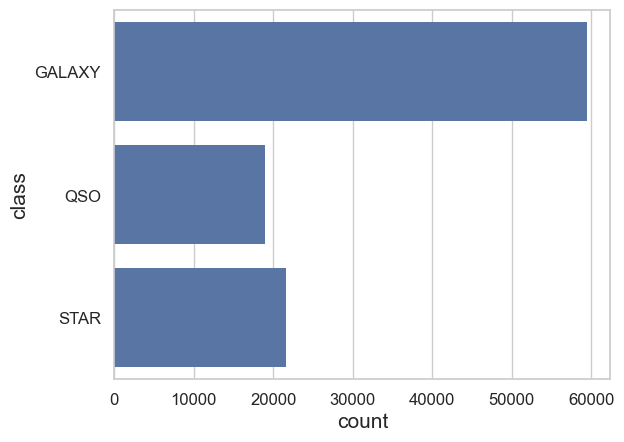

In [11]:
sns.countplot(cosmic_raw['class'])

In [12]:
cosmic_raw.isnull().sum().sum()

np.int64(0)

In [13]:
cosmic_raw.duplicated().sum()

np.int64(0)

In [14]:
cosmic_raw.columns

Index(['obj_ID', 'alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'run_ID',
       'rerun_ID', 'cam_col', 'field_ID', 'spec_obj_ID', 'class', 'redshift',
       'plate', 'MJD', 'fiber_ID'],
      dtype='str')

In [15]:
non_phys_cols = ['obj_ID', 'run_ID', 'rerun_ID', 'cam_col', 'field_ID', 'spec_obj_ID', 'plate', 'MJD', 'fiber_ID']
cosmic_phys = cosmic_raw.drop(columns=non_phys_cols)

In [16]:
cosmic_phys

,alpha,delta,u,g,r,i,z,class,redshift
0,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,GALAXY,0.634794
1,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,GALAXY,0.779136
2,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,GALAXY,0.644195
3,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,GALAXY,0.932346
4,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,GALAXY,0.116123
...,...,...,...,...,...,...,...,...,...
99995,39.620709,-2.594074,22.16759,22.97586,21.90404,21.30548,20.73569,GALAXY,0.000000
99996,29.493819,19.798874,22.69118,22.38628,20.45003,19.75759,19.41526,GALAXY,0.404895
99997,224.587407,15.700707,21.16916,19.26997,18.20428,17.69034,17.35221,GALAXY,0.143366
99998,212.268621,46.660365,25.35039,21.63757,19.91386,19.07254,18.62482,GALAXY,0.455040


In [17]:
cosmic_phys.describe()

,alpha,delta,u,g,r,i,z,redshift
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,177.629117,24.135305,21.980468,20.531387,19.645762,19.084854,18.668810,0.576661
std,96.502241,19.644665,31.769291,31.750292,1.854760,1.757895,31.728152,0.730707
min,0.005528,-18.785328,-9999.000000,-9999.000000,9.822070,9.469903,-9999.000000,-0.009971
25%,127.518222,5.146771,20.352353,18.965230,18.135828,17.732285,17.460677,0.054517
50%,180.900700,23.645922,22.179135,21.099835,20.125290,19.405145,19.004595,0.424173
75%,233.895005,39.901550,23.687440,22.123767,21.044785,20.396495,19.921120,0.704154
max,359.999810,83.000519,32.781390,31.602240,29.571860,32.141470,29.383740,7.011245


In [18]:
photo_filters = ['u', 'g', 'r', 'i', 'z']
print("\nScanning for implicit missing values / extreme imaging dropouts...")
anomalous_mask = cosmic_phys[photo_filters].apply(lambda x: (x < 0) | (x > 50)).any(axis=1)

if anomalous_mask.sum() > 0:
    print(f"-> Detected {anomalous_mask.sum()} rows containing severe invalid data profiles.")
    print(cosmic_phys[anomalous_mask][photo_filters])
    cosmic = cosmic_phys[~anomalous_mask].copy()
    print("   Dropped anomalous records successfully.")
else:
    cosmic = cosmic_phys.copy()
    print("   No underlying numerical anomalies found.")


Scanning for implicit missing values / extreme imaging dropouts...
-> Detected 1 rows containing severe invalid data profiles.
            u       g        r         i       z
79543 -9999.0 -9999.0  18.1656  18.01675 -9999.0
   Dropped anomalous records successfully.


In [19]:
cosmic.shape

(99999, 9)

In [20]:
cosmic.describe()

,alpha,delta,u,g,r,i,z,redshift
count,99999.000000,99999.000000,99999.000000,99999.000000,99999.000000,99999.000000,99999.000000,99999.000000
mean,177.628653,24.135552,22.080679,20.631583,19.645777,19.084865,18.768988,0.576667
std,96.502612,19.644608,2.251068,2.037384,1.854763,1.757900,1.765982,0.730709
min,0.005528,-18.785328,10.996230,10.498200,9.822070,9.469903,9.612333,-0.009971
25%,127.517698,5.147477,20.352410,18.965240,18.135795,17.732280,17.460830,0.054522
50%,180.900527,23.646462,22.179140,21.099930,20.125310,19.405150,19.004600,0.424176
75%,233.895005,39.901582,23.687480,22.123775,21.044790,20.396510,19.921120,0.704172
max,359.999810,83.000519,32.781390,31.602240,29.571860,32.141470,29.383740,7.011245


In [21]:
# Note: Significant drop in the std values of the features, 'u','g' & 'z' can be observed above

# Exploratory Data Analysis

In [22]:
cosmic.sample(5)

,alpha,delta,u,g,r,i,z,class,redshift
44721,247.572710,39.174651,21.61566,20.59395,20.41491,20.30441,19.98754,QSO,2.353671
90609,239.205067,42.933763,20.48557,19.42965,18.92563,18.72069,18.57971,STAR,-0.000467
67770,246.911188,39.437155,22.31978,21.54743,21.16063,20.93603,21.68513,QSO,1.111172
53391,168.196464,65.024021,20.16800,19.40164,19.00698,18.69670,18.61708,GALAXY,0.193597
88522,206.960781,46.382413,22.62081,23.63534,22.20564,20.67518,19.69340,GALAXY,0.946419


-> Exported Slide Graphic: eda_class_distribution.png


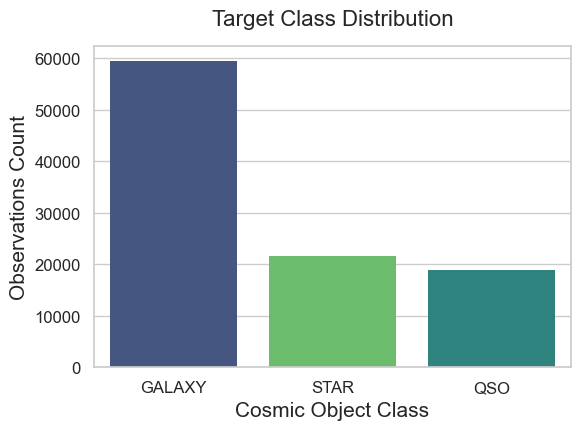

In [23]:
# --- A. Class Distribution (Slide Compact Shape) ---
# Perfect 4:3 grid presentation format (6x4.5 inches)
plt.figure(figsize=(6, 4.5))
class_counts = cosmic['class'].value_counts()
sns.countplot(data=cosmic, x='class', order=class_counts.index, hue='class', palette='viridis')
plt.title("Target Class Distribution", pad=15)
plt.xlabel("Cosmic Object Class")
plt.ylabel("Observations Count")
plt.tight_layout()
plt.savefig("eda_class_distribution.png", dpi=150)
print("-> Exported Slide Graphic: eda_class_distribution.png")
plt.show()
plt.close()

In [25]:
# Feature Engineering specific color-indices for astronomical scatter spaces
cosmic['u_g'] = cosmic['u'] - cosmic['g']
cosmic['g_r'] = cosmic['g'] - cosmic['r']
cosmic['r_i'] = cosmic['r'] - cosmic['i']
cosmic['i_z'] = cosmic['i'] - cosmic['z']

# DATA PREPROCESSING: CLASS LABELLING & DATA NORMALIZATION

In [26]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [27]:
label_encoder = LabelEncoder()

In [28]:
cosmic['class_encoded'] = label_encoder.fit_transform(cosmic['class'])

In [29]:
cosmic.head()

,alpha,delta,u,g,r,i,z,class,redshift,u_g,g_r,r_i,i_z,class_encoded
0,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,GALAXY,0.634794,1.60352,1.88029,1.22928,0.37202,0
1,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,GALAXY,0.779136,1.94571,0.24744,1.41632,-0.44615,0
2,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,GALAXY,0.644195,2.59918,2.05413,1.26119,0.40030,0
3,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,GALAXY,0.932346,-1.63974,2.16494,1.10708,1.25444,0
4,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,GALAXY,0.116123,1.85690,1.08281,0.52036,0.43250,0


In [30]:
cosmic['class'].value_counts()

class
GALAXY    59445
STAR      21593
QSO       18961
Name: count, dtype: int64

In [31]:
cosmic['class_encoded'].value_counts()

class_encoded
0    59445
2    21593
1    18961
Name: count, dtype: int64

In [32]:
print("Class Labeling Mapping:")
for numeric_label, text_label in enumerate(label_encoder.classes_):
    print(f"  {text_label} -> {numeric_label}")

Class Labeling Mapping:
  GALAXY -> 0
  QSO -> 1
  STAR -> 2


In [33]:
label_encoder.classes_

array(['GALAXY', 'QSO', 'STAR'], dtype=object)

In [34]:
# Separating the features and target

In [35]:
features = ['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift']

In [36]:
# Extracting the features (X) and the encodeding target (y)

In [37]:
X = cosmic[features].values
y = cosmic['class_encoded'].values

## Stratified Train-Test Split (Hold out 20% for pure final evaluation)

In [41]:
from sklearn.model_selection import train_test_split

In [42]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

## Standardize/Normalize the Split Data:

In [43]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# OPTIMIZED AUTOMATED BALANCING, TUNING & TRAINING

In [44]:
from imblearn.over_sampling import BorderlineSMOTE
from imblearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

In [45]:
# Constructing the Deployment Pipeline (Oversampler + Classifier)
# Using imblearn's pipeline to prevent data leakage during inner CV

In [46]:
rf_pipeline = Pipeline([
    ('smote', BorderlineSMOTE(kind='borderline-1', random_state=42)),
    ('classifier', RandomForestClassifier(random_state=42))
])

In [47]:
# Defining the exact same Hyperparameter Grid as used previously

In [48]:
param_grid = {
    'classifier__n_estimators': [50, 100],
    'classifier__max_depth': [10, None]
}

In [49]:
# Initializing GridSearchCV (Inner CV = 5-folds)

In [58]:
grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

In [59]:
# Executing the Grid Search on our scaled Training set

In [60]:
print("Training and tuning the Random Forest Model...")
grid_search.fit(X_train_scaled, y_train)
print("Training completed.")

Training and tuning the Random Forest Model...
Training completed.


# EXTRACTING FINAL EVALUATION METRICS

In [61]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

In [62]:
# Isolate the optimal trained model

In [63]:
best_rf_model = grid_search.best_estimator_

In [64]:
# Generate final predictions on the unseen test set

In [65]:
y_pred = best_rf_model.predict(X_test_scaled)
y_proba = best_rf_model.predict_proba(X_test_scaled)

In [66]:
# Calculate all standard evaluation metrics

In [67]:
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='macro')
recall    = recall_score(y_test, y_pred, average='macro')
f1        = f1_score(y_test, y_pred, average='macro')
roc_auc   = roc_auc_score(y_test, y_proba, multi_class='ovr', average='macro')

In [68]:
# Display Results

In [69]:
print("==================== FINAL EVALUATION METRICS ====================")
print(f"Optimal Hyperparameters: {grid_search.best_params_}")
print(f"Accuracy:                {accuracy:.4f}")
print(f"Precision (Macro):       {precision:.4f}")
print(f"Recall (Macro):          {recall:.4f}")
print(f"F1-Score (Macro):        {f1:.4f}")
print(f"ROC AUC (OvR Macro):     {roc_auc:.4f}")
print("==================================================================")

==================== FINAL EVALUATION METRICS ====================
Optimal Hyperparameters: {'classifier__max_depth': None, 'classifier__n_estimators': 100}
Accuracy:                0.9722
Precision (Macro):       0.9632
Recall (Macro):          0.9741
F1-Score (Macro):        0.9685
ROC AUC (OvR Macro):     0.9953


In [70]:
print("==================== FINAL EVALUATION METRICS ====================")
print(f"Optimal Hyperparameters: {grid_search.best_params_}")
print(f"Accuracy:                {accuracy:.4f}")
print(f"Precision (Macro):       {precision:.4f}")
print(f"Recall (Macro):          {recall:.4f}")
print(f"F1-Score (Macro):        {f1:.4f}")
print(f"ROC AUC (OvR Macro):     {roc_auc:.4f}")
print("==================================================================")

==================== FINAL EVALUATION METRICS ====================
Optimal Hyperparameters: {'classifier__max_depth': None, 'classifier__n_estimators': 100}
Accuracy:                0.9722
Precision (Macro):       0.9632
Recall (Macro):          0.9741
F1-Score (Macro):        0.9685
ROC AUC (OvR Macro):     0.9953


## PRODUCTION INFERENCE TESTING

In [71]:
print("==================== PRODUCTION PREDICTION CHECKS ====================\n")

# --- Sample 1: Galaxy Verification ---
sampleQ1 = [135.689107, 32.494632, 23.87882, 22.27530, 20.39501, 19.16573, 18.79371, 0.634794]
# Transform raw values into a 2D format and apply the training standardizer
q1_array = np.array([sampleQ1])
q1_scaled = scaler.transform(q1_array)
# Feed into our trained Random Forest pipeline and decode index back into string
q1_encoded = best_rf_model.predict(q1_scaled)[0]
outputQ1 = label_encoder.inverse_transform([q1_encoded])[0]
print(f"sampleQ1 -> Classified As: {outputQ1}")


# --- Sample 2: Quasar/QSO Verification ---
sampleQ2 = [340.995121, 20.589476, 23.48827, 23.33776, 21.32195, 20.25615, 19.54544, 1.424659]
q2_array = np.array([sampleQ2])
q2_scaled = scaler.transform(q2_array)
q2_encoded = best_rf_model.predict(q2_scaled)[0]
outputQ2 = label_encoder.inverse_transform([q2_encoded])[0]
print(f"sampleQ2 -> Classified As: {outputQ2}")


# --- Sample 3: Star Verification ---
sampleQ3 = [39.149691, 28.102842, 21.74669, 20.03493, 19.17553, 18.81823, 18.65422, -0.000008]
q3_array = np.array([sampleQ3])
q3_scaled = scaler.transform(q3_array)
q3_encoded = best_rf_model.predict(q3_scaled)[0]
outputQ3 = label_encoder.inverse_transform([q3_encoded])[0]
print(f"sampleQ3 -> Classified As: {outputQ3}\n")

print("======================================================================")

==================== PRODUCTION PREDICTION CHECKS ====================

sampleQ1 -> Classified As: GALAXY
sampleQ2 -> Classified As: QSO
sampleQ3 -> Classified As: STAR



## FILE EXPORT FOR WEB-FRAMEWORK IMPLEMENTATION

In [72]:
import joblib

# Bundling the final trained pipeline model with its preprocessing transformers
framework_production_artifacts = {
    "pipeline": best_rf_model,  # The optimized model pipeline (includes BorderlineSMOTE internally)
    "scaler": scaler,  # The trained StandardScaler used to normalize features
    "label_encoder": label_encoder,  # The trained LabelEncoder used to decode predictions back to strings
    "features": features,  # List of feature string names for documentation/validation
}

# Saving into a high-performance compressed file
joblib.dump(framework_production_artifacts, "cosmic_objects_rf_pipeline.pkl")
print(
    "Production pipeline file successfully created: 'cosmic_objects_rf_pipeline.pkl'"
)

Production pipeline file successfully created: 'cosmic_objects_rf_pipeline.pkl'
